# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
# importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from scipy.stats import ttest_ind, levene, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


 **Hallazgos del dataset:**

* El dataset tiene 40,000 registros y 9 columnas, sin valores nulos (`Non-Null Count` = 40,000 en todas)
* Las columnas categóricas (`landing`, `region`, `dispositivo`, `traffic_source`, `user_type`) están como `object`, tipo correcto para su naturaleza
* `converted` es `int64` (0/1), correcto, es la variable binaria del experimento
* `gasto` es `float64`, correcto
* `date` está como `object` (texto), debería ser `datetime` para poder calcular correctamente rango de fechas, ordenar cronológicamente o hacer operaciones temporales
* user_id es tipo object (string/texto) de forma correcta

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
print("Total de registros:", len(df))
print("Usuarios únicos:", df['user_id'].nunique())
print("Duplicados:", df['user_id'].duplicated().sum())

Total de registros: 40000
Usuarios únicos: 40000
Duplicados: 0



 **Variable `date`**  
Explorar rango de fechas


In [7]:


# Resumen estadístico
df['date'] = pd.to_datetime(df['date'])
df["date"].describe()



count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [8]:


# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())



Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [9]:

# Resumen estadístico
df['gasto'].describe()


count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:


# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\nColumna: {col}")
    print(df[col].value_counts())




Conteo de categorías:

Columna: landing
B    20018
A    19982
Name: landing, dtype: int64

Columna: region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Columna: dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Columna: traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Columna: user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


**Análisis de Variables Categóricas**

Al explorar la distribución de las variables categóricas mediante `value_counts()`, se observan las siguientes características:

* `landing`: se confirman únicamente las dos variantes esperadas del experimento (A con 19,982 registros y B con 20,018 registros), presentando una distribución prácticamente balanceada (~50/50)
* `region`: contiene los 5 valores esperados (`Norte`, `Centro`, `Sur`, `Occidente`, `Oriente`) sin duplicados por inconsistencias de formato o errores tipográficos
* `dispositivo`: incluye únicamente las categorías esperadas (`Mobile` y `Desktop`)
* `traffic_source`: muestra exclusivamente las fuentes de tráfico contempladas (`Organic`, `Ads`, `Email`, `Referral`)
* `user_type`: registra únicamente las clasificaciones esperadas (`Nuevo` y `Recurrente`)

**Conclusión**

Todas las columnas tienen valores esperados. No se identifican errores de captura, categorías mal escritas, valores nulos ni valores fuera del alcance del experimento. Se puede continuar con la siguiente fase del proceso sin necesidad de aplicar transformaciones o limpieza adicional en estas variables.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

Se filtraron los usuarios que realizaron una compra (`converted == 1`) para comparar el gasto entre variantes
* La versión A cuenta con 2,512 usuarios convertidos
* La versión B cuenta con 3,194 usuarios convertidos


### Prueba t de Student para muestras independientes

**Hipótesis:**

* Hipótesis nula ($H_0$): no existe diferencia en el gasto promedio de los usuarios entre la versión A y la versión B
* Hipótesis alternativa ($H_1$): existe una diferencia en el gasto promedio de los usuarios entre la versión A y la versión B


In [13]:

# Aplicar prueba
stat, p_value = ttest_ind(gasto_A, gasto_B)

In [14]:

# Visualizar resultados
print(f"Estadístico: {stat}")
print(f"Valor p: {p_value}")


Estadístico: -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación


**Decisión:**
Se rechaza la hipótesis nula ($H_0$), dado que el valor p obtenido es menor al nivel de significancia α = 0.05.

**Interpretación de negocio:**
Con base en la prueba t de Student, existe evidencia estadística de que el gasto promedio de los usuarios convertidos difiere entre la página A y la página B. Este resultado se basa en una muestra de usuarios que sí realizaron una compra y no evalúa la tasa de conversión entre páginas.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z de proporciones para muestras independientes

**Hipótesis:**
* **Hipótesis nula ($H_0$):** no existe diferencia en la tasa de conversión entre la versión A y la versión B
* **Hipótesis alternativa ($H_1$):** existe una diferencia en la tasa de conversión entre la versión A y la versión B

In [15]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [16]:
# Pasar a formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

In [17]:

# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%}).")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")


Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%).


### 📝 Conclusión e interpretación

**Decisión:**  
Valor p muchísimo menor que α = 0.05 → se rechaza H₀. Hay evidencia estadística de una diferencia real en la tasa de conversión entre A y B.

**Interpretación de negocio:**  

* La página B presenta una tasa de conversión de 15.96%, superior a la de la página A con 12.57%, una diferencia de 3.38 puntos porcentuales
* Este resultado indica que la página B es más efectiva para convertir usuarios en clientes
* Sin embargo, no evalúa si esta diferencia es suficiente para justificar el costo de implementación desde una perspectiva de negocio

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi-cuadrada de independencia

**Hipótesis:**

* Hipótesis nula ($H_0$): la conversión es independiente de la fuente de tráfico (no existe relación entre las variables)
* Hipótesis alternativa ($H_1$): la conversión depende de la fuente de tráfico (existe una relación entre las variables)

In [18]:


# Tabla de contingencia
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla_trafico)



converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [19]:


# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)



Estadístico chi-cuadrado: 8.662
Valor p: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [20]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

# Tabla de contingencia normalizada (tasas de conversión por canal)
tabla_trafico_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
print(tabla_trafico_normalizada)

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.
converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163



### 📝 Conclusión e interpretación

**Decisión:**
Se rechaza la hipótesis nula ($H_0$), dado que el valor p obtenido (0.034) es menor al nivel de significancia α = 0.05. Sin embargo, el valor p está cerca del umbral, por lo que la evidencia de asociación es más débil que en las pruebas anteriores.


**Interpretación de negocio:**

* Con base en la prueba chi-cuadrada de independencia (`chi2 = 8.662`, `p = 0.034`), existe evidencia estadística de que la conversión está asociada a la fuente de tráfico
* Al observar las tasas de conversión por canal, `Email` (14.99%) y `Ads` (14.74%) presentan las tasas más altas. Sin embargo, en términos de cantidades absolutas, `Organic` es el canal con más usuarios (17,987) y más conversiones totales (2,480), a pesar de tener la tasa de conversión más baja (13.79%), en comparación con las conversiones totales de `Email` (918) y `Ads` (1,759)
* Este resultado se basa en los `40,000` usuarios expuestos al experimento y no implica causalidad directa: la asociación no prueba que el canal en sí determine la conversión, podrían influir otros factores (por ejemplo, el tipo de usuario que llega por cada canal). Tampoco evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio (por ejemplo, redistribuir presupuesto entre canales). La diferencia entre el canal con mejor y peor tasa es de apenas 1.2 puntos porcentuales, una magnitud pequeña que, aunque estadísticamente significativa, podría no justificar por sí sola una reasignación de presupuesto entre canales



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.


### Prueba chi-cuadrada de independencia

**Hipótesis:**

* Hipótesis nula ($H_0$): la conversión es independiente del tipo de usuario (no existe relación entre las variables)
* Hipótesis alternativa ($H_1$): la conversión depende del tipo de usuario (existe una relación entre las variables)

In [21]:
# Tabla de contingencia
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])
print(tabla_usuario)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [22]:
# Tabla de contingencia normalizada (tasas de conversión por tipo de usuario)
tabla_usuario_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
print(tabla_usuario_normalizada)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [23]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

# Interpretar resultados
alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Estadístico chi-cuadrado: 0.513
Valor p: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**

No se rechaza la hipótesis nula ($H_0$), dado que el valor p obtenido (0.474) es considerablemente mayor al nivel de significancia α = 0.05.

**Interpretación de negocio:**

* Con base en la prueba chi-cuadrada de independencia (`chi2 = 0.513`, `p = 0.474`), no existe evidencia estadística de que la conversión esté asociada al tipo de usuario
* Las tasas de conversión son prácticamente idénticas entre ambos grupos: `Nuevo` (14.36%) y `Recurrente` (14.09%), una diferencia de apenas 0.27 puntos porcentuales, lo que indica que ambos perfiles se comportan de forma equivalente frente a las páginas A y B
* Este resultado se basa en los `40,000` usuarios expuestos al experimento. Aunque la tasa de conversión sea igual entre ambos grupos, eso no significa que tratar igual a nuevos y recurrentes sea la mejor decisión de marketing, ya que factores como el costo de retención o el mensaje más efectivo para cada perfil quedan fuera del alcance de esta prueba

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [30]:
# Tabla de contingencia
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])
orden_canales = ['Email', 'Organic', 'Ads', 'Referral']

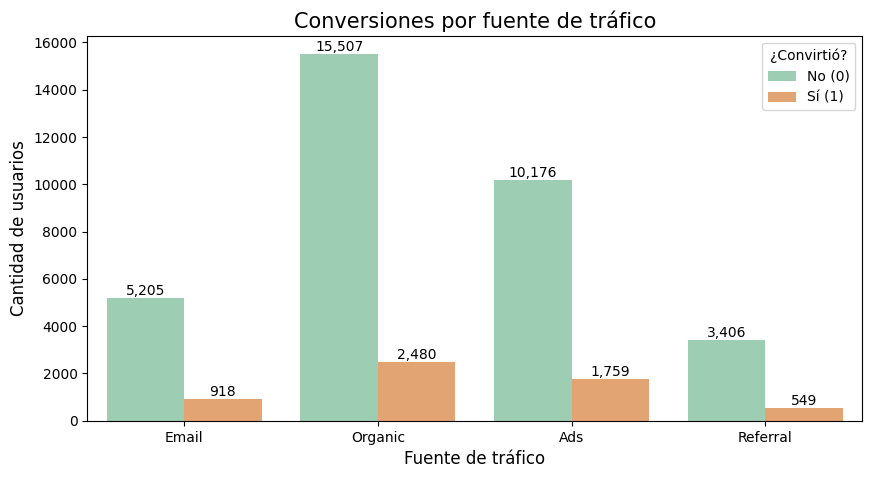

In [32]:
# Gráfico de barras agrupadas con valores
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"], order=orden_canales)

# Agregar valores encima de cada barra, con separador de miles
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x() + bar.get_width() / 2,
            y=height,
            s=f"{height:,.0f}",
            ha='center',
            va='bottom',
            fontsize=10)

plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

El gráfico de barras agrupadas muestra la cantidad absoluta de usuarios por fuente de tráfico, separados entre los que convirtieron y los que no. `Organic` concentra el mayor volumen de usuarios y también el mayor número de conversiones en términos absolutos, seguido de `Ads`. `Email` y `Referral` tienen un volumen considerablemente menor, aunque como vimos en la prueba chi-cuadrada, `Email` presenta la tasa de conversión relativa más alta a pesar de su bajo volumen.

In [28]:
# Tabla de contingencia normalizada
tabla_trafico_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

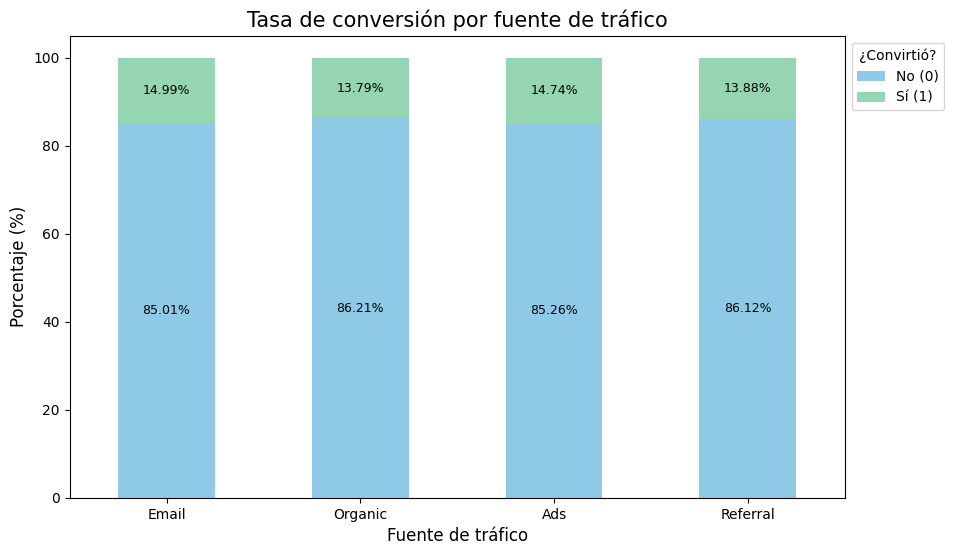

In [34]:
# Gráfico de barras apiladas con porcentajes centrados en cada segmento
ax = tabla_trafico_norm.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

# Agregar porcentajes centrados en cada segmento de la barra
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  # evita mostrar etiquetas en segmentos vacíos
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_y() + height / 2  # centro vertical del segmento
        ax.text(x, y, f"{height:.2f}%", ha='center', va='center', fontsize=9, color='black')

plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

El gráfico de barras apiladas muestra la tasa de conversión relativa por fuente de tráfico, independientemente del volumen total de usuarios. A diferencia del gráfico anterior (donde `Organic` dominaba en volumen), aquí se observa que las proporciones de conversión son más parejas entre canales, con `Email` y `Ads` mostrando una proporción de conversión ligeramente mayor (visible en el segmento verde superior) frente a `Organic` y `Referral`.

Esto confirma el hallazgo de la prueba chi-cuadrada (p = 0.034): existe una diferencia real entre canales, pero es pequeña, no es un caso donde un canal claramente supera al resto y otro queda muy por debajo.

### Relación entre el tipo de usuario y la conversión

In [35]:
orden_usuario = ['Nuevo', 'Recurrente']

# Tabla de contingencia
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

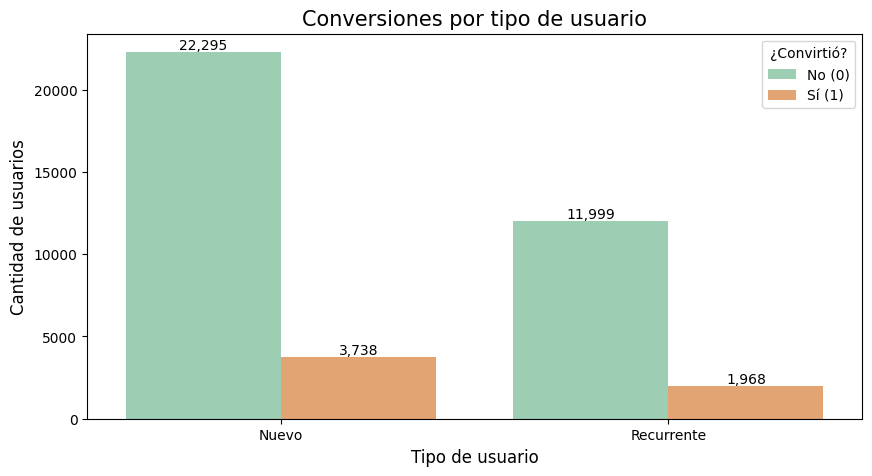

In [36]:
# Gráfico de barras agrupadas con valores
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"], order=orden_usuario)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x() + bar.get_width() / 2,
            y=height,
            s=f"{height:,.0f}",
            ha='center',
            va='bottom',
            fontsize=10)

plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

El gráfico de barras agrupadas muestra la cantidad absoluta de usuarios por tipo de usuario, separados entre los que convirtieron y los que no. El grupo `Nuevo` tiene el mayor volumen de usuarios (26,033 en total) y también el mayor número de conversiones (3,738), mientras que `Recurrente` tiene un volumen menor (13,967 en total) y menos conversiones (1,968).

In [37]:
# Tabla de contingencia normalizada
tabla_usuario_norm = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_usuario_norm = tabla_usuario_norm.reindex(orden_usuario)

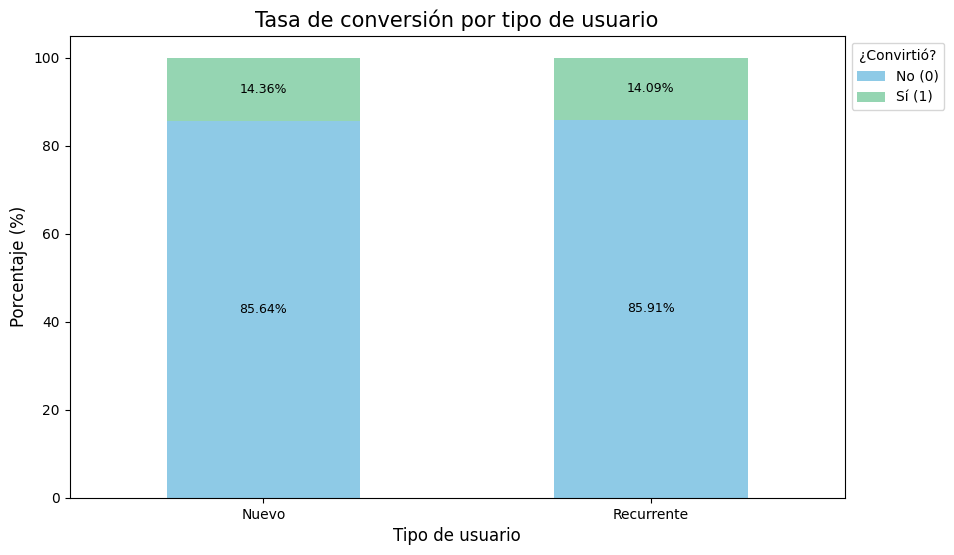

In [38]:
# Gráfico de barras apiladas con porcentajes centrados en cada segmento
ax = tabla_usuario_norm.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_y() + height / 2
        ax.text(x, y, f"{height:.2f}%", ha='center', va='center', fontsize=9, color='black')

plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

El gráfico de barras apiladas muestra la tasa de conversión relativa por tipo de usuario. Las proporciones son casi idénticas entre `Nuevo` (14.36%) y `Recurrente` (14.09%), una diferencia de apenas 0.27 puntos porcentuales. Esto confirma visualmente el resultado de la prueba chi-cuadrada (p = 0.474): no existe evidencia de una asociación entre el tipo de usuario y la conversión, ambos perfiles se comportan de forma prácticamente equivalente frente a las páginas A y B.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**


**Gasto promedio por usuario que convirtió:**
- La prueba t de Student mostró una diferencia estadísticamente significativa en el gasto promedio entre ambas versiones (`t = -9.37`, `p = 1.06e-20`)
- La página B genera un gasto promedio de **68.75 USD** por usuario convertido, superior a los **61.09 USD** de la página A, una diferencia de **7.66 USD** por usuario (un incremento de aproximadamente **12.5%**)
- **Interpretación:** Más allá de atraer conversiones, la página B también genera transacciones de mayor valor económico por usuario, reforzando su superioridad en ingresos
<br>

**Tasa de conversión:**
- La prueba z de proporciones confirmó una diferencia estadísticamente significativa en la tasa de conversión (`z = -9.68`, `p = 3.76e-22`)
- La página B convierte al **15.96%** de sus usuarios, frente a **12.57%** de la página A, una diferencia de **3.38 puntos porcentuales**
- **Interpretación:** La página B es consistentemente superior tanto en efectividad de conversión como en valor generado por usuario, lo que la posiciona como la versión recomendada para implementación

---

#### 📊 **Segmentación por fuente de tráfico**
- La prueba chi-cuadrada detectó una asociación débil pero estadísticamente significativa entre la fuente de tráfico y la conversión (`chi2 = 8.662`, `p = 0.034`); `Email` (**14.99%**) y `Ads` (**14.74%**) presentan las tasas más altas, mientras que `Organic`, con mayor volumen (17,987 usuarios, 2,480 conversiones), tiene la tasa más baja (**13.79%**)
- **Interpretación:** La diferencia entre canales es real pero pequeña (1.2 puntos porcentuales). Para decidir si vale la pena mover presupuesto entre canales, hace falta considerar otros factores que esta prueba no mide, como cuánto cuesta conseguir un usuario por cada canal y qué tan fácil es aumentar el tráfico de cada uno
    
 ---

#### 📊 **Segmentación por tipo de usuario**
- La prueba chi-cuadrada no encontró evidencia de asociación entre el tipo de usuario y la conversión (`chi2 = 0.513`, `p = 0.474`); las tasas son prácticamente idénticas entre `Nuevo` (**14.36%**) y `Recurrente` (**14.09%**)
- **Interpretación:** El tipo de usuario no es un factor relevante para explicar diferencias en conversión dentro de este experimento. Como ambos grupos convierten de forma prácticamente igual, no se recomienda crear versiones diferenciadas de la landing page según el tipo de usuario, ya que no hay evidencia de que aporte una mejora
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Implementar la página B como versión definitiva, dado que supera consistentemente a la página A tanto en tasa de conversión como en gasto promedio por usuario, con evidencia estadística sólida en ambos casos
- Investigar por qué `Email` y `Ads` convierten mejor que `Organic` antes de mover presupuesto entre canales. Aunque tengan mejor tasa de conversión, si el costo de conseguir cada usuario por esos canales es mucho más alto que por `Organic`, la ventaja podría no valer la pena